#Librerías

Importación de librerías.

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
#Google Drive
drive.mount('/content/drive')

# Ruta
file_path = "/content/drive/MyDrive/Colab Notebooks/IDA_DATA.csv"

# Leer el archivo CSV
df = pd.read_csv(file_path)

Mounted at /content/drive


<ipython-input-2-523b8b05d16c>:8: DtypeWarning: Columns (23,24,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


#Limpieza

Análisis visual de las variables de los datos.

In [ ]:
df.head()

,End of Period,Credit Number,Region,Country / Economy Code,Country / Economy,Borrower,Credit Status,Service Charge Rate,Currency of Commitment,Project ID,...,Repaid 3rd Party (US$),Due 3rd Party (US$),Credits Held (US$),First Repayment Date,Last Repayment Date,Agreement Signing Date,Board Approval Date,Effective Date (Most Recent),Closed Date (Most Recent),Last Disbursement Date
0,06/30/2022,IDA00010,LATIN AMERICA AND CARIBBEAN,HN,Honduras,MINISTERIO DE HACIENDA Y CREDITO PUBLICO,Fully Repaid,0.75,USD,P007335,...,0.0,0.0,0.0,09/01/1971,03/01/2011,05/12/1961,05/11/1961,06/29/1961,07/31/1967,NaN
1,01/31/2013,IDA00010,LATIN AMERICA AND CARIBBEAN,HN,Honduras,MINISTERIO DE HACIENDA Y CREDITO PUBLICO,Fully Repaid,0.75,USD,P007335,...,0.0,0.0,0.0,09/01/1971,03/01/2011,05/12/1961,05/11/1961,06/29/1961,07/31/1967,NaN
2,02/28/2013,IDA00010,LATIN AMERICA AND CARIBBEAN,HN,Honduras,MINISTERIO DE HACIENDA Y CREDITO PUBLICO,Fully Repaid,0.75,USD,P007335,...,0.0,0.0,0.0,09/01/1971,03/01/2011,05/12/1961,05/11/1961,06/29/1961,07/31/1967,NaN
3,03/31/2013,IDA00010,LATIN AMERICA AND CARIBBEAN,HN,Honduras,MINISTERIO DE HACIENDA Y CREDITO PUBLICO,Fully Repaid,0.75,USD,P007335,...,0.0,0.0,0.0,09/01/1971,03/01/2011,05/12/1961,05/11/1961,06/29/1961,07/31/1967,NaN
4,04/30/2013,IDA00010,LATIN AMERICA AND CARIBBEAN,HN,Honduras,MINISTERIO DE HACIENDA Y CREDITO PUBLICO,Fully Repaid,0.75,USD,P007335,...,0.0,0.0,0.0,09/01/1971,03/01/2011,05/12/1961,05/11/1961,06/29/1961,07/31/1967,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1411251 entries, 0 to 1411250
Data columns (total 30 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   End of Period                    1411251 non-null  object 
 1   Credit Number                    1411251 non-null  object 
 2   Region                           1411251 non-null  object 
 3   Country / Economy Code           1411251 non-null  object 
 4   Country / Economy                1411251 non-null  object 
 5   Borrower                         1410807 non-null  object 
 6   Credit Status                    1411251 non-null  object 
 7   Service Charge Rate              1239775 non-null  float64
 8   Currency of Commitment           1411251 non-null  object 
 9   Project ID                       1411250 non-null  object 
 10  Project Name                     1411196 non-null  object 
 11  Original Principal Amount (US$)  1411251 non-null 

Revisión de datos faltantes por columna.

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.round(2).sort_values(ascending=False)

,0
Last Disbursement Date,31.30
First Repayment Date,16.85
Last Repayment Date,16.85
Service Charge Rate,12.15
Agreement Signing Date,1.41
Effective Date (Most Recent),0.93
Borrower,0.03
Closed Date (Most Recent),0.02
Country / Economy,0.00
Credit Status,0.00


##Formatos

In [ ]:
#Formatosde las fechas y de la columna de 'Region'
date_columns = [
    'End of Period', 'First Repayment Date', 'Last Repayment Date',
    'Agreement Signing Date', 'Board Approval Date', 'Effective Date (Most Recent)',
    'Closed Date (Most Recent)', 'Last Disbursement Date']
df[date_columns] = df[date_columns].apply(pd.to_datetime, errors='coerce')
df['Region'] = df['Region'].str.upper()

##Revisión de las filas

In [ ]:
# Verificar si hay filas duplicadas
duplicados = df.duplicated()
print(f"Número total de filas duplicadas: {duplicados.sum()}")
print(f"Porcentaje de duplicados: {duplicados.mean()*100:.2f}%")

In [ ]:
#Eliminación de la columna 'Last Disbursement Date'
df = df.drop(columns=['Last Disbursement Date'])
#Eliminación de los datos nulos de las columnas 'Disbursed Amount (US$)', 'Repaid to IDA (US$)'
df.dropna(subset=['Disbursed Amount (US$)', 'Repaid to IDA (US$)'], inplace=True)

In [ ]:
#Llenar los nombres del proyecto
df['Project Name'] = df['Project Name'].fillna('Unknown')

In [ ]:
#Eliminar los nulos de la variable 'Closed Date (Most Recent)'
df = df.dropna(subset=['Closed Date (Most Recent)'])

In [ ]:
#Revisión de las categorías del prestario.
df['Borrower'].unique()

array(['MINISTERIO DE HACIENDA Y CREDITO PUBLICO',
       'Ministry of Finance and Economy Planning',
       'Ministry of Finance and National Economy',
       'Ministry of Finance & Economic Planning',
       'CONTROLLER OF AID ACCOUNTS & AUDIT',
       'MINISTERIO DE OBRAS PUBLICAS', 'MINISTRY OF FINANCE',
       'MINISTERIO DE HACIENDA', 'MINISTRY OF ECONOMIC AFFAIRS',
       'Ministry of Finance and Economic Affairs',
       'Ministerio de Hacienda',
       'MINISTRY OF PLANNING & INTNL COOPERATION',
       'THE ACCOUNTANT GENERAL', 'MINISTRY OF STRATEGY AND FINANCE',
       'MINISTERIO DE LA CONSTRUCCION',
       'Ministere du Plan Et du Dev. Regional',
       'MINISTRO DE OBRAS PUBLICAS',
       "MINISTERE DE L'ECONOMIE ET DES FINANCES",
       'UNDERSECRETARIAT OF TREASURY', 'Ministry of Treasury and Finance',
       'Ministry of Finance and Eco Development', 'Ministry of Finance',
       'Ministry of Finance and Eco Cooperation',
       'Ministry of Finance and Planning', 'MINI

In [ ]:
print((df['Sold 3rd Party (US$)']>0).value_counts())
print('------------------------------------------------')
print((df['Repaid 3rd Party (US$)']>0).value_counts())
print('------------------------------------------------')
print((df['Credits Held (US$)']>0).value_counts())
print('------------------------------------------------')
print((df['Exchange Adjustment (US$)']>0).value_counts())

In [ ]:
df['Service Charge Rate'].describe()

,Service Charge Rate
count,1.239638e+06
mean,8.062305e-01
std,4.935749e-01
min,0.000000e+00
25%,7.500000e-01
50%,7.500000e-01
75%,7.500000e-01
max,7.090000e+00


In [ ]:
#Imputar los NaN con la moda en la columna 'Service Charge Rate'
mode_rate = df['Service Charge Rate'].mode()[0]
df['Service Charge Rate'] = df['Service Charge Rate'].fillna(mode_rate)
print(f"Valor usado para imputar: {mode_rate}")
print(f"Nulos restantes: {df['Service Charge Rate'].isna().sum()}")

Valor usado para imputar: 0.75
Nulos restantes: 0


##Categorias

Categorización de la columna "Credit Number".

In [ ]:
def classify_ida(id_number):
    prefix_types = {
        'IDAB': 'Guarantee',
        'IDAG': 'Guarantee',
        'IDAD': 'Grant',
        'IDAH': 'Grant',
        'IDAE': 'Grant'
    }
    # Verificar los primeros 4 caracteres
    prefix = id_number[:4]
    return prefix_types.get(prefix, 'Credit')

df['Type'] = df['Credit Number'].apply(classify_ida)

Categorización de la columna "Credit Status".

In [ ]:
status_mapping = {
    "Repaying": "Activo",
    "Disbursing": "Activo",
    "Disbursed": "Activo",
    "Fully Disbursed": "Activo",
    "Disbursing&Repaying": "Activo",
    "Effective": "Activo",
    "Fully Repaid": "Reembolsado",
    "Repaid": "Reembolsado",
    "Fully Cancelled": "Cancelado",
    "Cancelled": "Cancelado",
    "Signed": "No Desembolsado",
    "Approved": "No Desembolsado"
}

df['credit_status_group'] = df['Credit Status'].map(status_mapping)

Categorización de la columna "Borrower".

In [ ]:
def categorize_borrower(borrower):
    # Verificar si el valor es NaN o está vacío primero
    if pd.isna(borrower) or str(borrower).strip() == '':
        return 'other'

    borrower = str(borrower).lower()

    # 1. Ministerios de Finanzas
    finance_keywords = ['finance', 'hacienda', 'treasury', 'economy', 'budget']
    if any(keyword in borrower for keyword in finance_keywords):
        return 'finance_ministry'

    # 2. Bancos Centrales/Instituciones Financieras
    bank_keywords = ['bank', 'banco', 'central', 'reserve', 'caisse', 'fondo']
    if any(keyword in borrower for keyword in bank_keywords):
        return 'central_bank'

    # 3. Organizaciones Internacionales
    intl_keywords = ['un', 'world bank', 'undp', 'unicef', 'international',
                    'african', 'ecowas', 'commission', 'secretariat']
    if any(keyword in borrower for keyword in intl_keywords):
        return 'international_org'

    # 4. Empresas/Compañías Privadas
    company_keywords = ['company', 'ltd', 'inc', 'sa', 's.a.', 'power', 'energy']
    if any(keyword in borrower for keyword in company_keywords):
        return 'private_company'

    # 5. Otros Ministerios
    ministry_keywords = ['ministry', 'ministere', 'ministerio', 'secretaria']
    if any(keyword in borrower for keyword in ministry_keywords):
        return 'other_ministry'

    # 6. Casos especiales
    special_cases = {
        'controller of aid accounts & audit': 'aid_controller',
        '#multivalue': 'multivalue',
        'world food programme': 'un_agency'
    }
    for case, category in special_cases.items():
        if case in borrower:
            return category

    return 'other'

df['borrower_type'] = df['Borrower'].apply(categorize_borrower)

##Validación de columnas

<Axes: >

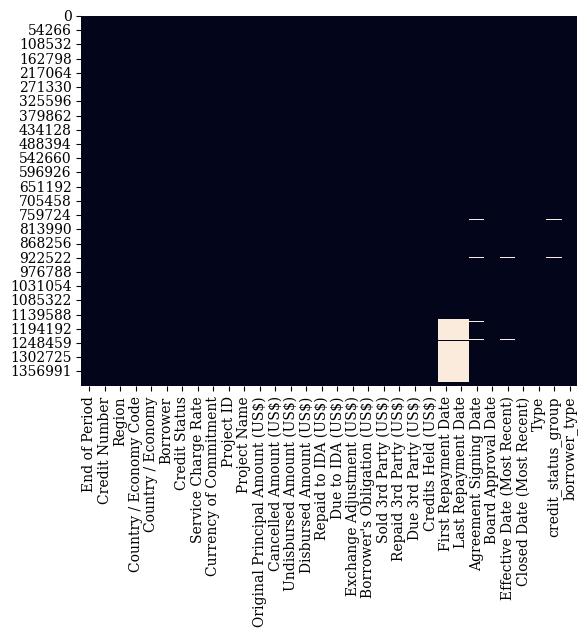

In [ ]:
mpl.rcParams['font.family'] = 'serif'
sns.heatmap(df.isnull(), cbar=False)

Validación de fechas en orden lógico.

In [ ]:
mask = (
    (df['Board Approval Date'] <= df['Agreement Signing Date']) &
    (df['Agreement Signing Date'] <= df['Effective Date (Most Recent)']) &
    (df['Effective Date (Most Recent)'] <= df['First Repayment Date']) &
    (df['First Repayment Date'] <= df['Last Repayment Date'])
)
df_inconsistent = df[~mask]

In [ ]:
#Mostrar el número total de filas inconsistentes
num_inconsistent = len(df_inconsistent)
print(f"📊 Total de filas con fechas inconsistentes: {num_inconsistent}")
print(f"📈 Porcentaje del dataset: {num_inconsistent/len(df)*100:.2f}%")
print("\n🔍 Ejemplos de registros inconsistentes:")
display(df_inconsistent[['Board Approval Date', 'Agreement Signing Date',
                        'Effective Date (Most Recent)', 'First Repayment Date',
                        'Last Repayment Date']].head())

📊 Total de filas con fechas inconsistentes: 263873
📈 Porcentaje del dataset: 18.70%

🔍 Ejemplos de registros inconsistentes:


,Board Approval Date,Agreement Signing Date,Effective Date (Most Recent),First Repayment Date,Last Repayment Date
41832,1971-03-23,1971-04-05,1971-12-29,1901-01-02,2020-11-15
41833,1971-03-23,1971-04-05,1971-12-29,1901-01-02,2020-11-15
41834,1971-03-23,1971-04-05,1971-12-29,1901-01-02,2020-11-15
41835,1971-03-23,1971-04-05,1971-12-29,1901-01-02,2020-11-15
41836,1971-03-23,1971-04-05,1971-12-29,1901-01-02,2020-11-15


In [ ]:
df = df[mask].copy()

In [ ]:
'''
# Ruta de guardado (ajusta "Colab Notebooks" si tu carpeta tiene otro nombre)
ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/IDA_LIMPIO.csv"

# Guardar el DataFrame con configuración profesional
df.to_csv(
    ruta_guardado,
    index=False,               # No guardar el índice
    encoding='utf-8-sig',      # Codificación para caracteres especiales
    float_format='%.2f',       # 2 decimales para valores numéricos
    date_format='%Y-%m-%d'     # Formato estándar de fechas
)

print(f"✅ Archivo guardado correctamente en:\n{ruta_guardado}")
'''

✅ Archivo guardado correctamente en:
/content/drive/MyDrive/Colab Notebooks/IDA_LIMPIO.csv


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1147036 entries, 0 to 1411250
Data columns (total 32 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   End of Period                    1147036 non-null  datetime64[ns]
 1   Credit Number                    1147036 non-null  object        
 2   Region                           1147036 non-null  object        
 3   Country / Economy Code           1147036 non-null  object        
 4   Country / Economy                1147036 non-null  object        
 5   Borrower                         1146669 non-null  object        
 6   Credit Status                    1147036 non-null  object        
 7   Service Charge Rate              1147036 non-null  float64       
 8   Currency of Commitment           1147036 non-null  object        
 9   Project ID                       1147036 non-null  object        
 10  Project Name                     11

In [ ]:
#Parámetros para las imágenes.

sns.set_style("whitegrid")  # Fondo con grid
sns.set_palette("husl")     # Paleta de colores
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.family': 'serif',        # Familia tipográfica
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Georgia'],  # Fuentes específicas
    'font.size': 12,               # Tamaño base
    'axes.titlesize': 16,          # Título del gráfico
    'axes.titleweight': 'bold',    # Títulos
    'axes.labelsize': 14,          # Etiquetas de ejes
    'xtick.labelsize': 12,         # Ticks del eje X
    'ytick.labelsize': 12,         # Ticks del eje Y
    'legend.fontsize': 12          # Leyenda
})


In [ ]:
# Diccionario de traducción de columnas
nombres_espanol = {
    'End of Period': 'Fin de Periodo',
    'Credit Number': 'Número de Credito',
    'Region': 'Región',
    'Country / Economy Code': 'Código de País/Economía',
    'Country / Economy': 'País/Economía',
    'Borrower': 'Prestatario',
    'Credit Status': 'Estado del Crédito',
    'Service Charge Rate': 'Tasa de Comisión de Servicio',
    'Currency of Commitment': 'Moneda del Compromiso',
    'Project ID': 'ID de Proyecto',
    'Project Name': 'Nombre del Proyecto',
    'Original Principal Amount (US$)': 'Monto Principal Original (US$)',
    'Cancelled Amount (US$)': 'Monto Cancelado (US$)',
    'Undisbursed Amount (US$)': 'Monto No Desembolsado (US$)',
    'Disbursed Amount (US$)': 'Monto Desembolsado (US$)',
    'Repaid to IDA (US$)': 'Reembolsado a AIF (US$)',
    'Due to IDA (US$)': 'Deuda con AIF (US$)',
    'Exchange Adjustment (US$)': 'Ajuste por Tipo de Cambio (US$)',
    'Borrower\'s Obligation (US$)': 'Obligación del Prestatario (US$)',
    'Sold 3rd Party (US$)': 'Vendido a Terceros (US$)',
    'Repaid 3rd Party (US$)': 'Reembolsado por Terceros (US$)',
    'Due 3rd Party (US$)': 'Deuda con Terceros (US$)',
    'Credits Held (US$)': 'Créditos en Cartera (US$)',
    'First Repayment Date': 'Fecha Primer Reembolso',
    'Last Repayment Date': 'Fecha ÚLltimo Reembolso',
    'Agreement Signing Date': 'Fecha de Firma del Acuerdo',
    'Board Approval Date': 'Fecha de Aprobación por Directorio',
    'Effective Date (Most Recent)': 'Fecha Efectiva (Mas Reciente)',
    'Closed Date (Most Recent)': 'Fecha de Cierre (Mas Reciente)',
    'Type': 'Tipo',
    'credit_status_group': 'Grupo de Estado de Crédito',
    'borrower_type': 'Tipo de Prestatario'
}
# Renombrar las columnas del DataFrame
df = df.rename(columns=nombres_espanol)
print(df.columns.tolist())

['Fin de Periodo', 'Número de Credito', 'Región', 'Código de País/Economía', 'País/Economía', 'Prestatario', 'Estado del Crédito', 'Tasa de Comisión de Servicio', 'Moneda del Compromiso', 'ID de Proyecto', 'Nombre del Proyecto', 'Monto Principal Original (US$)', 'Monto Cancelado (US$)', 'Monto No Desembolsado (US$)', 'Monto Desembolsado (US$)', 'Reembolsado a AIF (US$)', 'Deuda con AIF (US$)', 'Ajuste por Tipo de Cambio (US$)', 'Obligación del Prestatario (US$)', 'Vendido a Terceros (US$)', 'Reembolsado por Terceros (US$)', 'Deuda con Terceros (US$)', 'Créditos en Cartera (US$)', 'Fecha Primer Reembolso', 'Fecha ÚLltimo Reembolso', 'Fecha de Firma del Acuerdo', 'Fecha de Aprobación por Directorio', 'Fecha Efectiva (Mas Reciente)', 'Fecha de Cierre (Mas Reciente)', 'Tipo', 'Grupo de Estado de Crédito', 'Tipo de Prestatario']


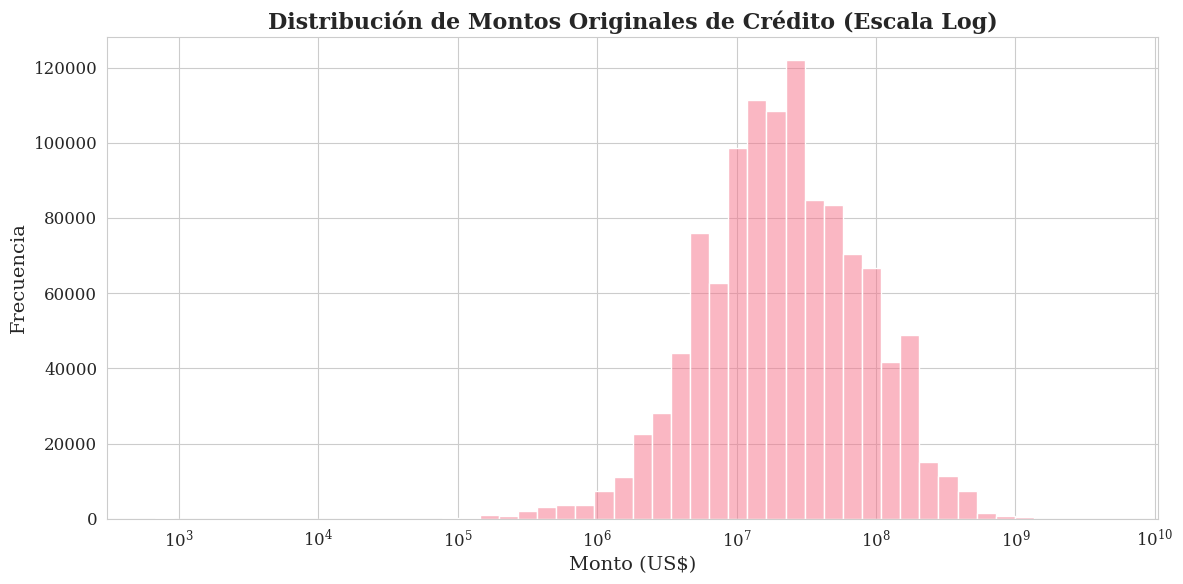

In [ ]:
# Histograma para montos financieros
fig, ax = plt.subplots()
sns.histplot(data=df, x='Monto Principal Original (US$)', bins=50, kde=True, log_scale=True)
ax.set_title('Distribución de Montos Originales de Crédito (Escala Log)')
ax.set_xlabel('Monto (US$)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

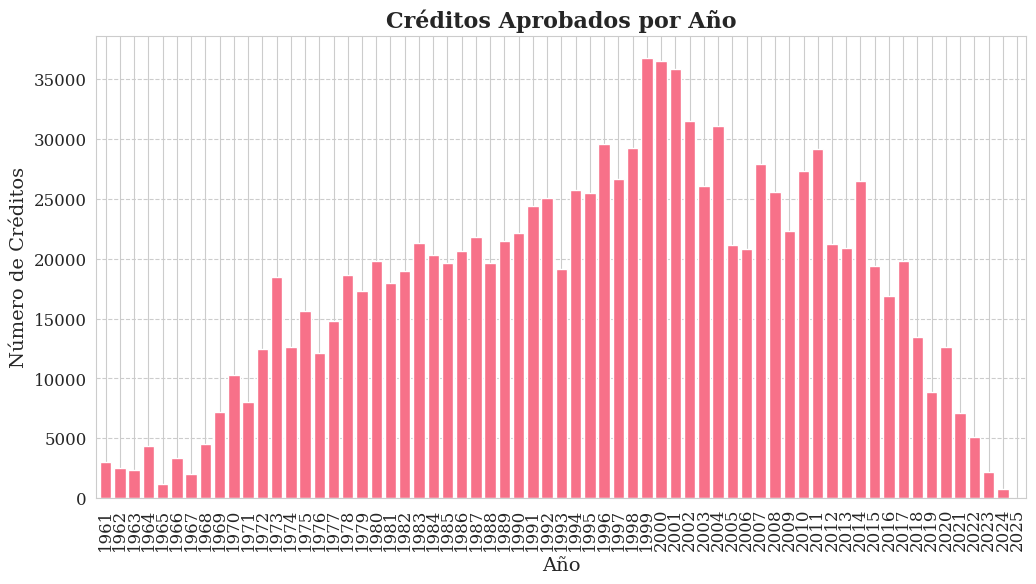

In [ ]:
# Evolución anual de créditos aprobados
df['Year'] = df['Fecha de Aprobación por Directorio'].dt.year
annual_credits = df.groupby('Year').size()

plt.figure()
annual_credits.plot(kind='bar', width=0.8, edgecolor='white')
plt.title('Créditos Aprobados por Año', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Créditos')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

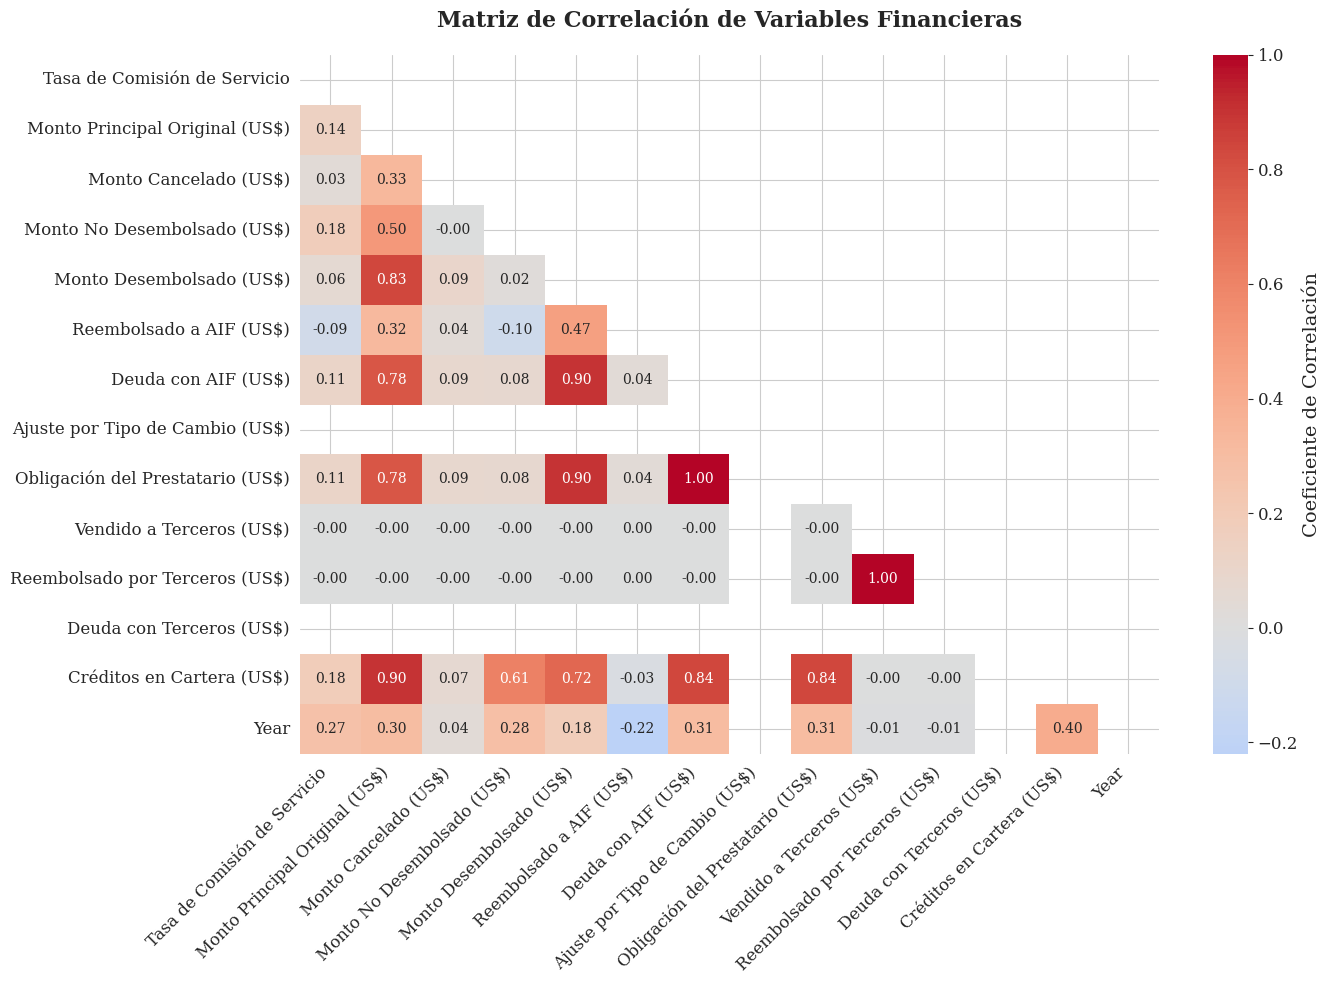

In [ ]:
# Seleccionar variables numéricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            annot_kws={"size": 10}, cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Matriz de Correlación de Variables Financieras', fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

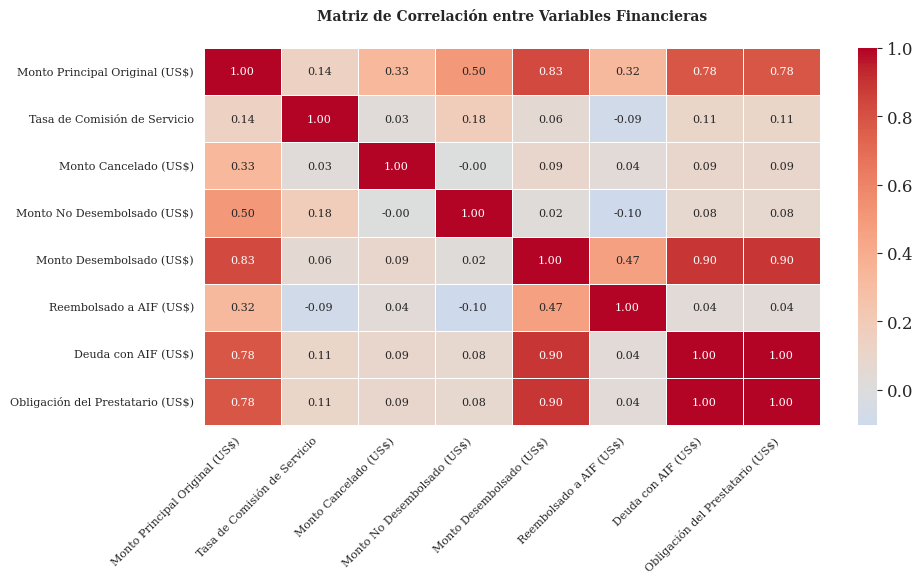

In [ ]:
#Seleccionar las columnas numéricas relevantes
columnas_interes = [
    'Monto Principal Original (US$)',
    'Tasa de Comisión de Servicio',
    'Monto Cancelado (US$)',
    'Monto No Desembolsado (US$)',
    'Monto Desembolsado (US$)',
    'Reembolsado a AIF (US$)',
    'Deuda con AIF (US$)',
    'Obligación del Prestatario (US$)'
]

df_corr = df[columnas_interes].copy()
matriz_correlacion = df_corr.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de 2 decimales
    cmap="coolwarm",  # Mapa de colores
    center=0,  # Punto neutro en 0
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matriz de Correlación entre Variables Financieras", pad=20, fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Valores traducidos: ['América Latina Y Caribe' 'África Oriental' 'África'
 'África Oriental Y Meridional' 'Asia Meridional'
 'Asia Oriental Y Pacífico' 'Medio Oriente Y Norte De África'
 'Europa Y Asia Central' 'África Occidental Y Central' 'África Occidental']


<ipython-input-41-bb2d7f22f3a4>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


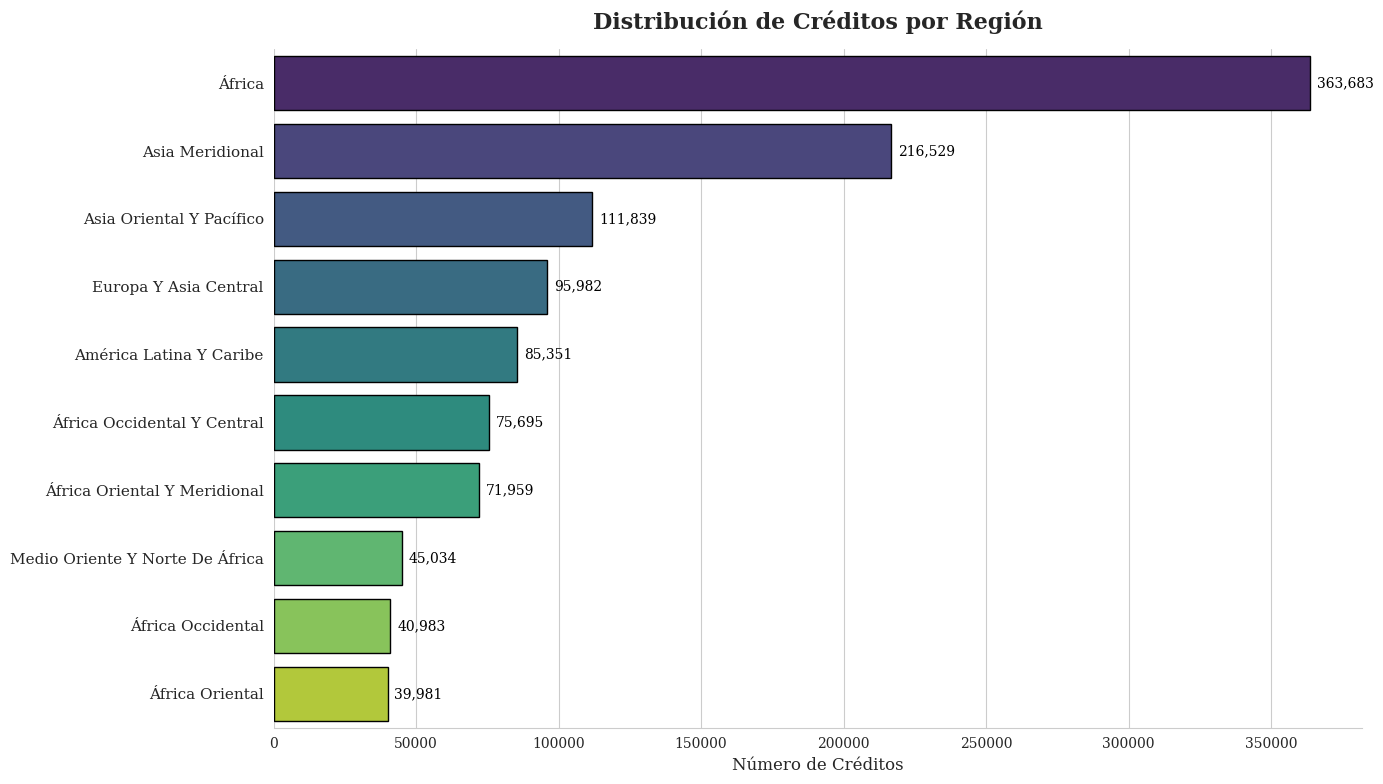

In [ ]:
traduccion_regiones = {
    # África
    'AFRICA': 'África',
    'AFRICA EAST': 'África Oriental',
    'AFRICA WEST': 'África Occidental',
    'EASTERN AND SOUTHERN AFRICA': 'África Oriental y Meridional',
    'WESTERN AND CENTRAL AFRICA': 'África Occidental y Central',

    # Otras regiones
    'LATIN AMERICA AND CARIBBEAN': 'América Latina y Caribe',
    'EAST ASIA AND PACIFIC': 'Asia Oriental y Pacífico',
    'SOUTH ASIA': 'Asia Meridional',
    'MIDDLE EAST AND NORTH AFRICA': 'Medio Oriente y Norte de África',
    'EUROPE AND CENTRAL ASIA': 'Europa y Asia Central'
}

# Aplicar traducción (convirtiendo a minúsculas primero para estandarizar)
df['Región'] = df['Región'].str.strip().str.lower().map(
    lambda x: traduccion_regiones.get(x.upper(), x.title())
)

# Verificación final
print("Valores traducidos:", df['Región'].unique())

plt.figure(figsize=(14, 8))
ax = sns.countplot(
    y='Región',
    data=df,
    order=df['Región'].value_counts().index,
    palette='viridis',
    edgecolor='black'
)

# Añadir etiquetas con formato
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{x:,.0f}' for x in container.datavalues],
        padding=5,
        fontsize=10,
        color='black'
    )

# Ajustes estéticos
plt.title('Distribución de Créditos por Región', fontsize=16, pad=15)
plt.xlabel('Número de Créditos', fontsize=12)
plt.ylabel('')
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)
sns.despine(left=True)

plt.tight_layout()
plt.show()

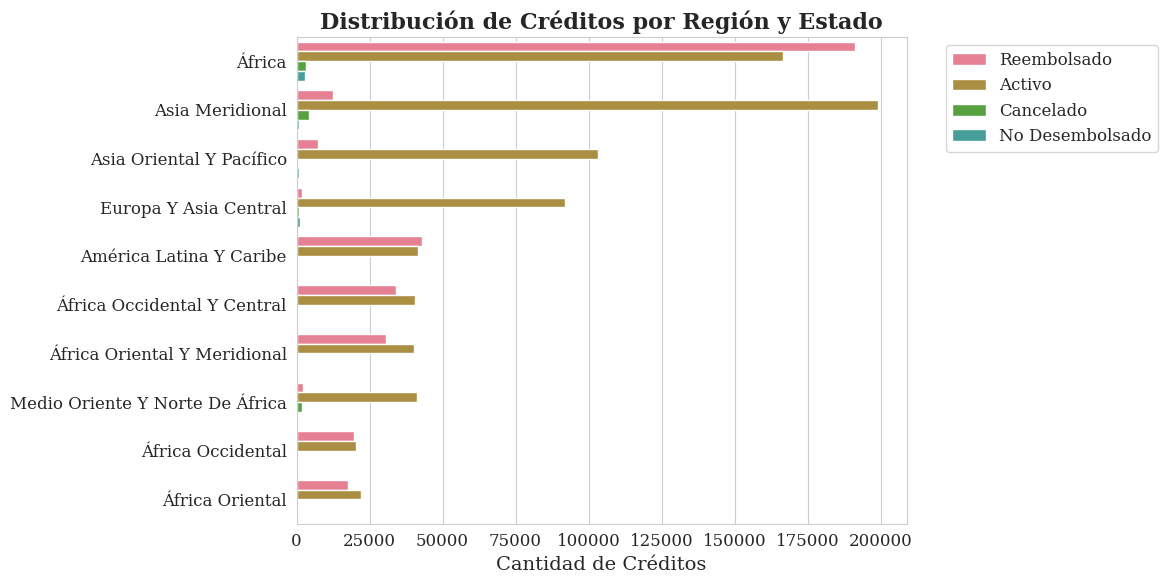

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Región', hue='Grupo de Estado de Crédito', data=df,
             order=df['Región'].value_counts().index)
plt.title('Distribución de Créditos por Región y Estado')
plt.xlabel('Cantidad de Créditos')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

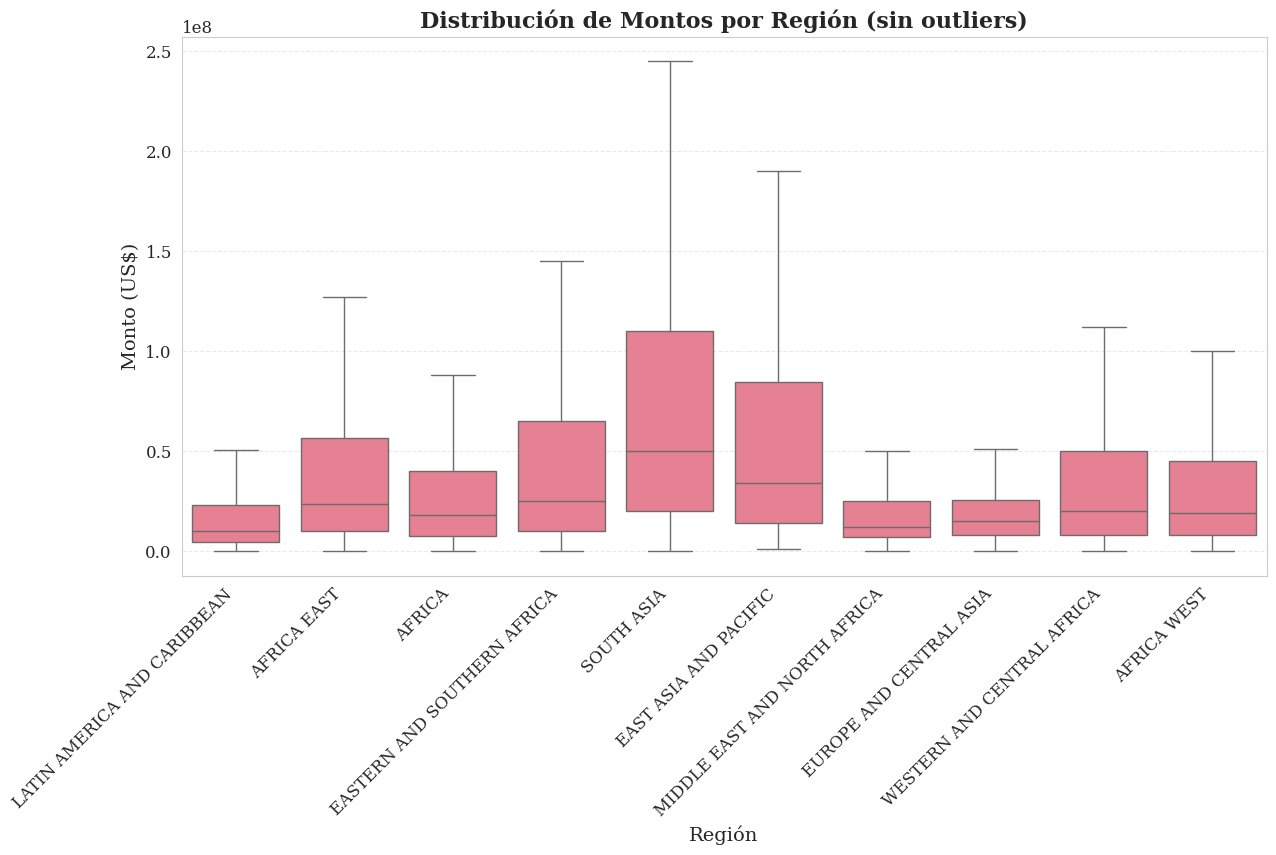

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Region', y='Original Principal Amount (US$)', showfliers=False)
plt.title('Distribución de Montos por Región (sin outliers)', fontweight='bold')
plt.xlabel('Región')
plt.ylabel('Monto (US$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

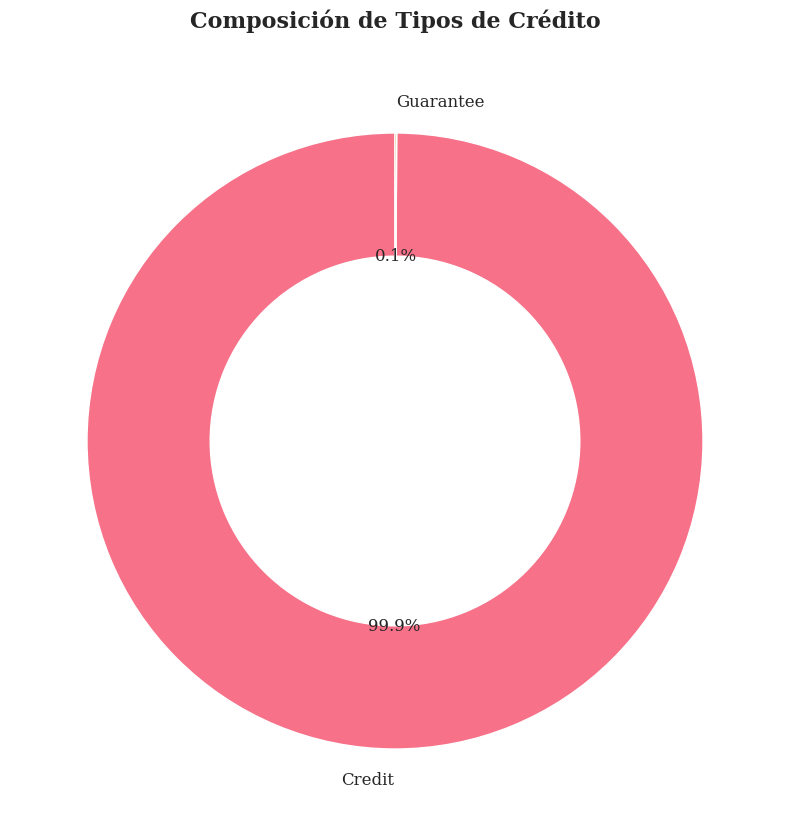

In [ ]:
# Gráfico de donut para tipos de crédito
type_counts = df['Tipo'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(width=0.4))
plt.title('Composición de Tipos de Crédito', fontweight='bold', pad=20)
plt.gca().add_artist(plt.Circle((0,0),0.3,fc='white'))  # Crea el efecto donut
plt.show()

<ipython-input-28-871c91a7f562>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_disbursements = df.set_index('Board Approval Date')['Disbursed Amount (US$)'].resample('M').sum()


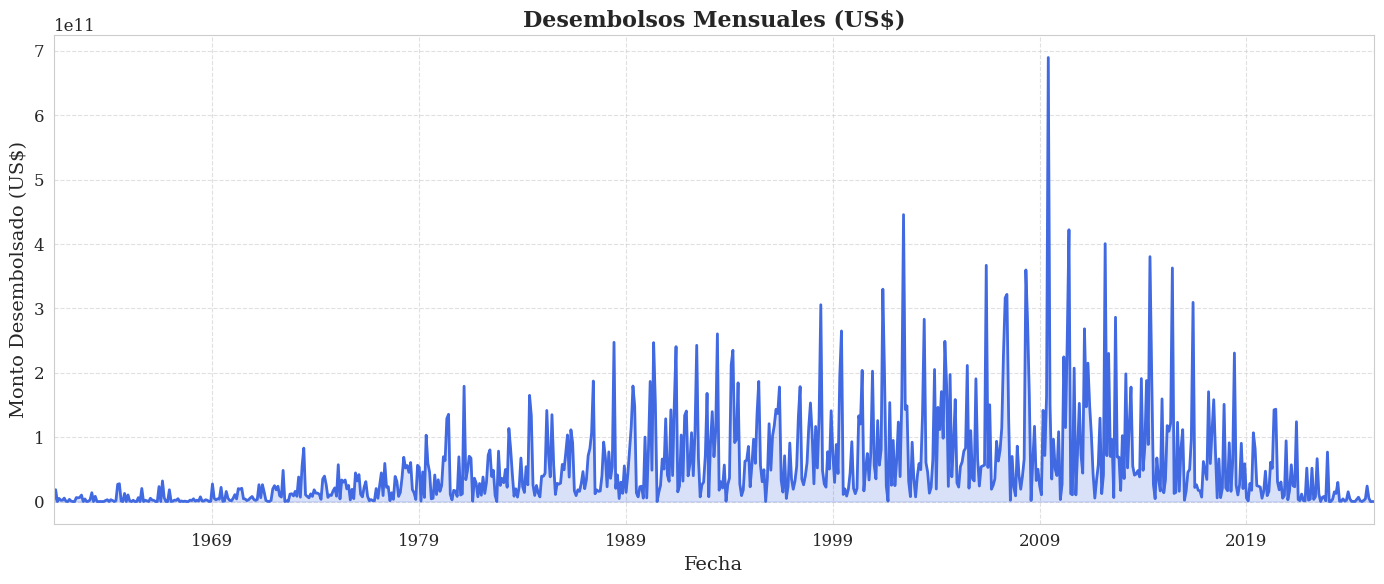

In [ ]:
# Preparar datos mensuales
monthly_disbursements = df.set_index('Board Approval Date')['Disbursed Amount (US$)'].resample('M').sum()

plt.figure(figsize=(14, 6))
monthly_disbursements.plot(color='royalblue', linewidth=2)
plt.title('Desembolsos Mensuales (US$)', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Monto Desembolsado (US$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.fill_between(monthly_disbursements.index, monthly_disbursements, alpha=0.2, color='royalblue')
plt.tight_layout()
plt.show()

<ipython-input-51-6e7982737895>:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if conteo_estados[i]/sum(conteo_estados) < 0.05:  # Para porciones pequeñas


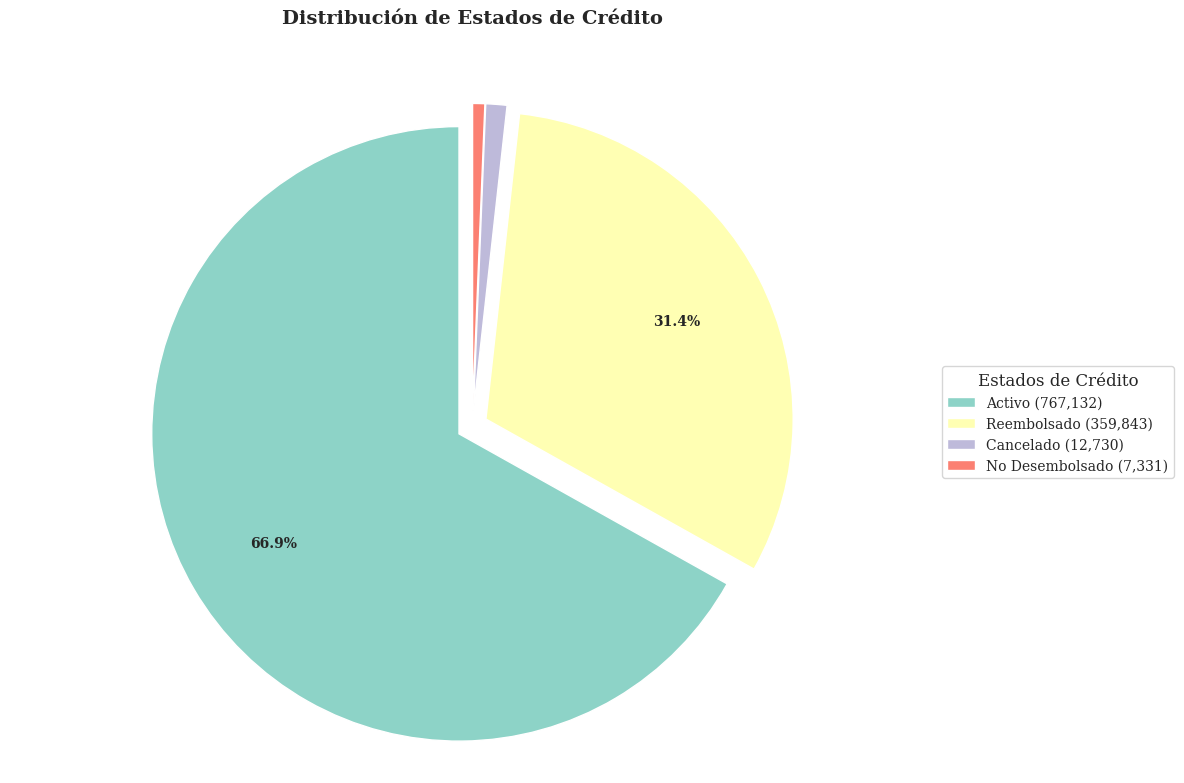

In [ ]:
conteo_estados = df['Grupo de Estado de Crédito'].value_counts()

plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    conteo_estados,
    labels=None,  # Eliminamos labels iniciales para mayor control
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '',  # Solo muestra % > 5%
    startangle=90,
    shadow=False,  # Más limpio sin sombra
    explode=[0.05] * len(conteo_estados),  # Separación uniforme
    colors=sns.color_palette('Set3'),
    pctdistance=0.8,  # Alejar porcentajes del centro
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

legend_labels = [f"{label} ({count:,})" for label, count in zip(conteo_estados.index, conteo_estados)]
plt.legend(
    wedges,
    legend_labels,
    title="Estados de Crédito",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

# 4. Ajustar posición de los porcentajes manualmente si es necesario
for i, (text, autotext) in enumerate(zip(texts, autotexts)):
    if conteo_estados[i]/sum(conteo_estados) < 0.05:  # Para porciones pequeñas
        autotext.set_visible(False)
    else:
        # Ajustar posición radial
        angle = (wedges[i].theta2 - wedges[i].theta1)/2 + wedges[i].theta1
        x = 0.75 * np.cos(np.deg2rad(angle))
        y = 0.75 * np.sin(np.deg2rad(angle))
        autotext.set_position((x, y))

# 5. Título y formato final
plt.title('Distribución de Estados de Crédito\n', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()